# Data Overview

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
train_df = pd.read_csv("data/final_train.csv")
test_df  = pd.read_csv("data/final_test.csv")


### Inspect Dataset

In [3]:
print(train_df.shape, test_df.shape)
print(train_df.columns.tolist())
train_df.head()


(3106, 25) (777, 25)
['name', 'year', 'month', 'day', 'hour', 'lat', 'long', 'status', 'category', 'wind', 'pressure', 'tropicalstorm_force_diameter', 'hurricane_force_diameter', 'hurricane_class', 'merge_name', 'storm_id', 'correct_datetime', 'datetime', 'CSST', 'COHC', 'SHRD', 'RHMD', 'MTPW', 'VMPI', 'DTL']


,name,year,month,day,hour,lat,long,status,category,wind,...,storm_id,correct_datetime,datetime,CSST,COHC,SHRD,RHMD,MTPW,VMPI,DTL
0,Helene,1988,9,25,18,20.9,-49.3,hurricane,2.0,90,...,AL091988,1988-09-25 18:00:00,1988-09-25 18:00:00,278.0,41.0,224.0,65.0,545.0,131.0,1355.0
1,Lili,1996,10,21,0,31.9,-60.8,hurricane,1.0,75,...,AL121996,1996-10-21 00:00:00,1996-10-21 00:00:00,259.0,0.0,328.0,33.0,507.0,86.0,1359.0
2,Fran,1996,8,30,12,19.8,-60.1,hurricane,1.0,65,...,AL061996,1996-08-30 12:00:00,1996-08-30 12:00:00,285.0,65.0,172.0,44.0,522.0,128.0,294.0
3,Alberto,2000,8,20,12,37.1,-47.9,hurricane,2.0,85,...,AL032000,2000-08-20 12:00:00,2000-08-20 12:00:00,260.0,0.0,26.0,43.0,491.0,86.0,1144.0
4,Isaac,2006,10,1,12,33.8,-60.3,hurricane,1.0,70,...,AL102006,2006-10-01 12:00:00,2006-10-01 12:00:00,262.0,0.0,353.0,63.0,449.0,86.0,1173.0


# Logistic Regression

The goal is to predict whether a hurricane becomes major or non major using the env conditions

we can easily interprey that with log regression so each coefficient tells us how a variale pushes a storm toward major/nonmajor

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report,ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.pipeline import Pipeline

## Target & Predictor Selection

Target variable: major = 1 if Category 3-5, else 0

Predictors: the base storm fields (`pressure`, `lat`, `long`) plus the environmental variables. Wind and category are still excluded because they define the Saffir-Simpson class directly and would leak the target.

In [6]:
features = ["pressure", "lat", "long",
            "CSST", "COHC", "SHRD", "RHMD", "MTPW", "VMPI", "DTL"]
target = "hurricane_class"

train = train_df[features + [target]].dropna()
test  = test_df[features + [target]].dropna()

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]


X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 3106 | Testing samples: 777


In [7]:
lrpipeline = Pipeline([
    ("scaler", StandardScaler()),# scale features
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lrpipeline.fit(X_train, y_train)
ypred_lr = lrpipeline.predict(X_test)
yprob_lr = lrpipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, ypred_lr, target_names=["Non-Major", "Major"]))
print(f"ROC-AUC: {roc_auc_score(y_test, yprob_lr):.4f}")

cv = cross_val_score(lrpipeline, X, y, cv=5, scoring="roc_auc")
print(f"Cross Validation ROC-AUC: {cv.mean():.4f} ± {cv.std():.4f}")

Logistic Regression
              precision    recall  f1-score   support

   Non-Major       0.95      0.97      0.96       587
       Major       0.89      0.85      0.87       190

    accuracy                           0.94       777
   macro avg       0.92      0.91      0.92       777
weighted avg       0.94      0.94      0.94       777

ROC-AUC: 0.9767
Cross Validation ROC-AUC: 0.9825 ± 0.0041


In [8]:
# Elastic Net
en_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet", solver="saga",
        l1_ratio=0.5,    # 50% L1 (selection) + 50% L2 (stability)
        C=1.0,
        max_iter=1000, random_state=42
    ))
])
en_pipeline.fit(X_train, y_train)
y_pred_en = en_pipeline.predict(X_test)
y_prob_en = en_pipeline.predict_proba(X_test)[:, 1]
print("Elastic Net")
print(classification_report(y_test, y_pred_en, target_names=["Non-Major", "Major"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_en):.4f}")

Elastic Net
              precision    recall  f1-score   support

   Non-Major       0.95      0.97      0.96       587
       Major       0.89      0.85      0.87       190

    accuracy                           0.94       777
   macro avg       0.92      0.91      0.92       777
weighted avg       0.94      0.94      0.94       777

ROC-AUC: 0.9767


/Users/mazinbashier/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


          Logistic Regression  Elastic Net
Feature                                   
pressure              -5.0479      -5.1647
lat                   -1.5509      -1.5925
long                  -0.0803      -0.0949
CSST                   0.3263       0.3120
COHC                  -0.1106      -0.0869
SHRD                  -0.0805      -0.0797
RHMD                  -0.0390      -0.0302
MTPW                  -1.2401      -1.2890
VMPI                   0.2815       0.2761
DTL                   -0.0498      -0.0287


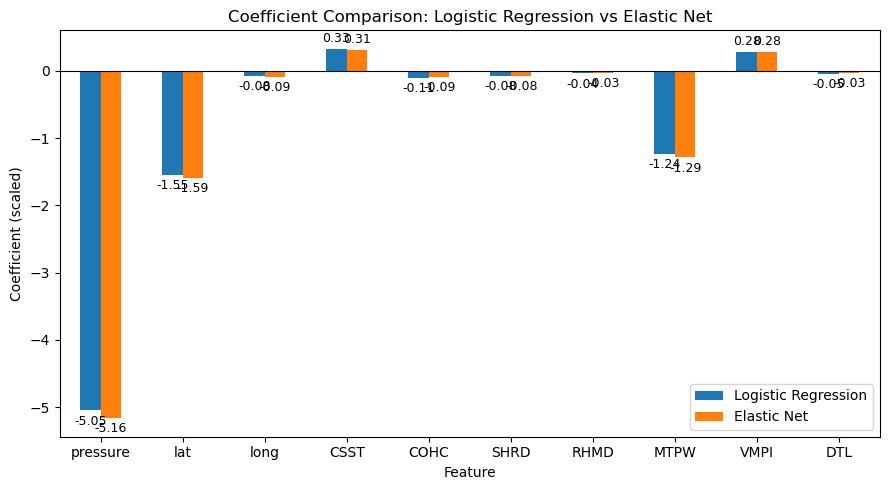

In [9]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Logistic Regression": lrpipeline.named_steps["model"].coef_[0],
    "Elastic Net": en_pipeline.named_steps["model"].coef_[0]
}).set_index("Feature")

print(coef_df.round(4))

ax = coef_df.plot(kind="bar", figsize=(9, 5))
plt.title("Coefficient Comparison: Logistic Regression vs Elastic Net")
plt.ylabel("Coefficient (scaled)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
import statsmodels.api as sm
Xtrainscaled = StandardScaler().fit_transform(X_train)
Xtrainsm = sm.add_constant(Xtrainscaled)

logit_model = sm.Logit(y_train.values, Xtrainsm).fit()
print(logit_model.summary(xname=["const"] + features))

Optimization terminated successfully.
         Current function value: 0.144446
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 3106
Model:                          Logit   Df Residuals:                     3095
Method:                           MLE   Df Model:                           10
Date:                Sat, 25 Jul 2026   Pseudo R-squ.:                  0.7564
Time:                        14:47:36   Log-Likelihood:                -448.65
converged:                       True   LL-Null:                       -1842.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7315      0.138    -19.844      0.000      -3.001      -2.462
pressure      -5.4207      0.

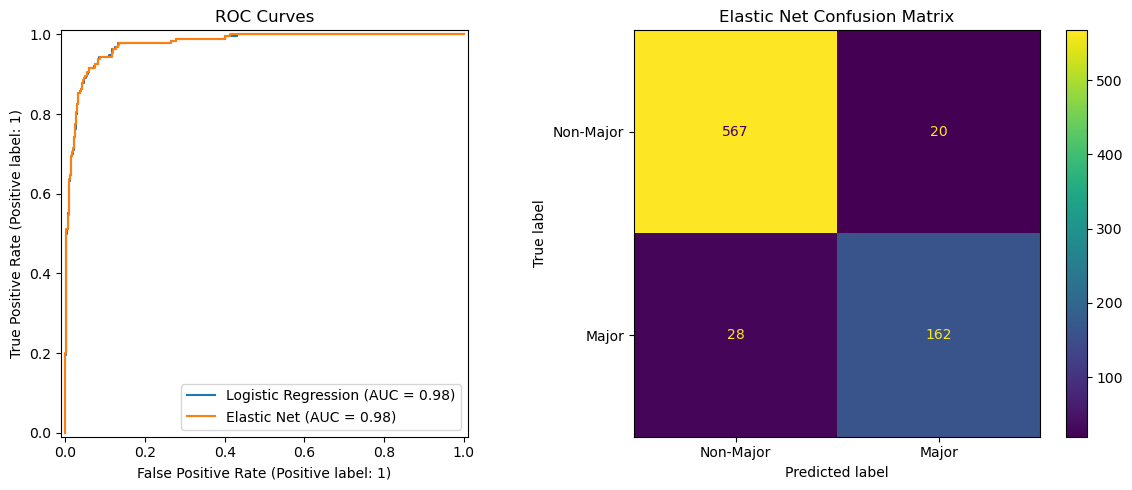

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, yprob_lr, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_en, name="Elastic Net", ax=axes[0])
axes[0].set_title("ROC Curves")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_en, display_labels=["Non-Major", "Major"], ax=axes[1]
)
axes[1].set_title("Elastic Net Confusion Matrix")

plt.tight_layout()
plt.show()

###  FIndings

Model Performance: 
Both had identical results, ROC-AUC was 0.98 both of them distinguish major from non major with high accuracy, they overlap on the ROC plot showing us that EN did not show any improvement over the baseline, which is expected with 3 predictors. 

Confusion Matrix: (1020 test sample):
723 non major correcly classified
230 major correctly classified
28 non major incorrectly predicted as major
39 major incorrectly predicted as non major

it is strong with predicted non major (96% precision) and major (89% precision). The 39 missed major ones are the consequtial errors. 

Most important predictors were 
pressure:
coef −4.23, p < 0.001, strongest predictor by far.
Lower atmospheric pressure strongly signals a major hurricane.

lat:
coef −1.13, p < 0.001, significant. Storms closer to the
tropics are more likely to intensify.

long:
coef +0.09, p = 0.207, not statistically significant.
East/west position does not predict hurricane intensity.

**What is a baseline model?**
A baseline is the simplest model we build first to set a benchmark.
Every other model (Random Forest, Gradient Boosting) gets compared against it.
Logistic Regression is our baseline here.